# Import

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import joblib

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.exceptions import NotFittedError
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text

import folium
from folium import LayerControl

# Lecture des csv

In [2]:
df_ventes = pd.read_csv('data/ech_annonces_ventes_68.csv', sep=';', index_col='idannonce')

In [3]:
X_train = pd.read_csv('X_train.csv', index_col="idannonce")
X_test = pd.read_csv('X_test.csv', index_col="idannonce")

X_train_sans_scaler = pd.read_csv('X_train_sans_scaler.csv', index_col="idannonce")
X_test_sans_scaler = pd.read_csv('X_test_sans_scaler.csv', index_col="idannonce")

y_train = pd.read_csv('y_train.csv', index_col="idannonce")
y_test = pd.read_csv('y_test.csv', index_col="idannonce")

# Suppression prix_m2_vente et renommage prix_bien_target_encoding

In [4]:
X_train = X_train.rename(columns={'prix_bien_target_encoding':'avg_commune_type_pieces'}).drop('prix_m2_vente', axis=1)
X_test = X_test.rename(columns={'prix_bien_target_encoding':'avg_commune_type_pieces'}).drop('prix_m2_vente', axis=1)
X_train_sans_scaler = X_train_sans_scaler.rename(columns={'prix_bien_target_encoding':'avg_commune_type_pieces'}).drop('prix_m2_vente', axis=1)
X_test_sans_scaler = X_test_sans_scaler.rename(columns={'prix_bien_target_encoding':'avg_commune_type_pieces'}).drop('prix_m2_vente', axis=1)

# Découpage X et y par type de bien

In [5]:
X_train_appartements = X_train[(X_train_sans_scaler['typedebien_lite_a'] == 1)]
X_train_sans_scaler_appartements = X_train_sans_scaler[(X_train_sans_scaler['typedebien_lite_a'] == 1)]
y_train_appartements = y_train[(X_train_sans_scaler['typedebien_lite_a'] == 1)]
X_test_appartements = X_test[(X_test_sans_scaler['typedebien_lite_a'] == 1)]
X_test_sans_scaler_appartements = X_test_sans_scaler[(X_test_sans_scaler['typedebien_lite_a'] == 1)]
y_test_appartements = y_test[(X_test_sans_scaler['typedebien_lite_a'] == 1)]

X_train_maisons = X_train[(X_train_sans_scaler['typedebien_lite_m'] == 1)]
X_train_sans_scaler_maisons = X_train_sans_scaler[(X_train_sans_scaler['typedebien_lite_m'] == 1)]
y_train_maisons = y_train[(X_train_sans_scaler['typedebien_lite_m'] == 1)]
X_test_maisons = X_test[(X_test_sans_scaler['typedebien_lite_m'] == 1)]
X_test_sans_scaler_maisons = X_test_sans_scaler[(X_test_sans_scaler['typedebien_lite_m'] == 1)]
y_test_maisons = y_test[(X_test_sans_scaler['typedebien_lite_m'] == 1)]

In [6]:
print(X_train.shape)
print(y_train.shape)
print(X_train_appartements.shape)
print(X_train_sans_scaler_appartements.shape)
print(y_train_appartements.shape)
print(X_train_maisons.shape)
print(X_train_sans_scaler_maisons.shape)
print(y_train_maisons.shape)

(20569, 93)
(20569, 1)
(10192, 93)
(10192, 93)
(10192, 1)
(10377, 93)
(10377, 93)
(10377, 1)


In [7]:
print(X_test.shape)
print(y_test.shape)
print(X_test_appartements.shape)
print(X_test_sans_scaler_appartements.shape)
print(y_test_appartements.shape)
print(X_test_maisons.shape)
print(X_test_sans_scaler_maisons.shape)
print(y_test_maisons.shape)

(5127, 93)
(5127, 1)
(2502, 93)
(2502, 93)
(2502, 1)
(2625, 93)
(2625, 93)
(2625, 1)


# Vérification de la distribution de surface entre X_train et X_test

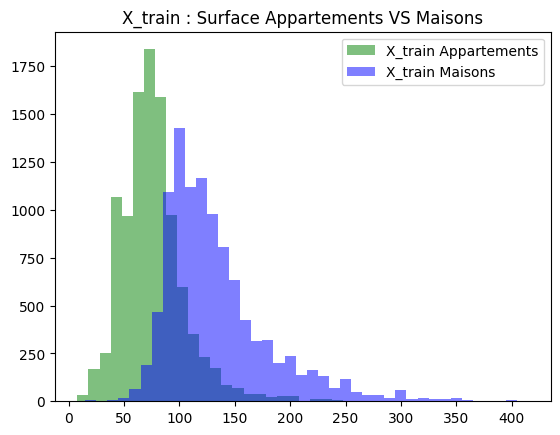

In [8]:
plt.hist(X_train_sans_scaler_appartements['surface'], color='green', alpha=0.5, label='X_train Appartements', bins=range(round(min(X_train_sans_scaler_appartements['surface'])), round(max(X_train_sans_scaler_appartements['surface'])), 10))
plt.hist(X_train_sans_scaler_maisons['surface'], color='blue', alpha=0.5, label='X_train Maisons', bins=range(round(min(X_train_sans_scaler_maisons['surface'])), round(max(X_train_sans_scaler_maisons['surface'])), 10))
plt.legend()
plt.title('X_train : Surface Appartements VS Maisons')
plt.show()


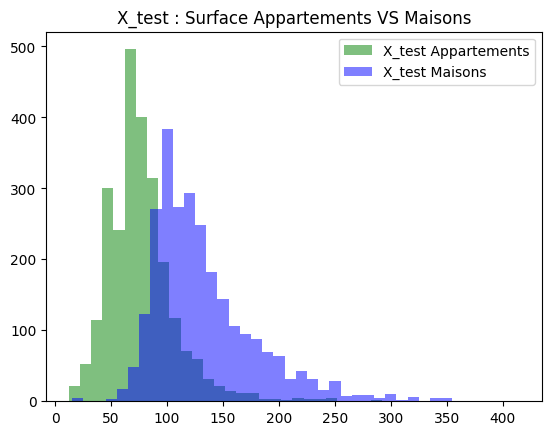

In [9]:
plt.hist(X_test_sans_scaler_appartements['surface'], color='green', alpha=0.5, label='X_test Appartements', bins=range(round(min(X_test_sans_scaler_appartements['surface'])), round(max(X_test_sans_scaler_appartements['surface'])), 10))
plt.hist(X_test_sans_scaler_maisons['surface'], color='blue', alpha=0.5, label='X_test Maisons', bins=range(round(min(X_test_sans_scaler_maisons['surface'])), round(max(X_test_sans_scaler_maisons['surface'])), 10))
plt.legend()
plt.title('X_test : Surface Appartements VS Maisons')
plt.show()


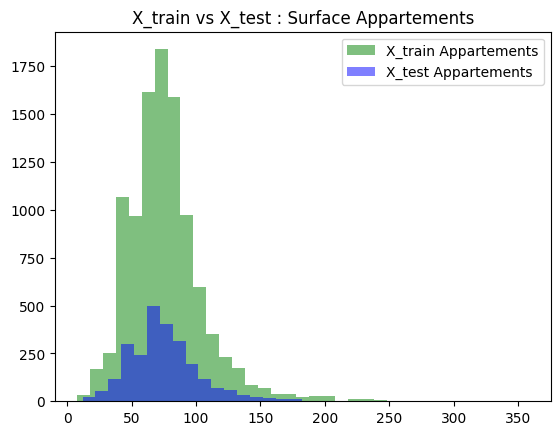

In [10]:
plt.hist(X_train_sans_scaler_appartements['surface'], color='green', alpha=0.5, label='X_train Appartements', bins=range(round(min(X_train_sans_scaler_appartements['surface'])), round(max(X_train_sans_scaler_appartements['surface'])), 10))
plt.hist(X_test_sans_scaler_appartements['surface'], color='blue', alpha=0.5, label='X_test Appartements', bins=range(round(min(X_test_sans_scaler_appartements['surface'])), round(max(X_test_sans_scaler_appartements['surface'])), 10))
plt.legend()
plt.title('X_train vs X_test : Surface Appartements')
plt.show()


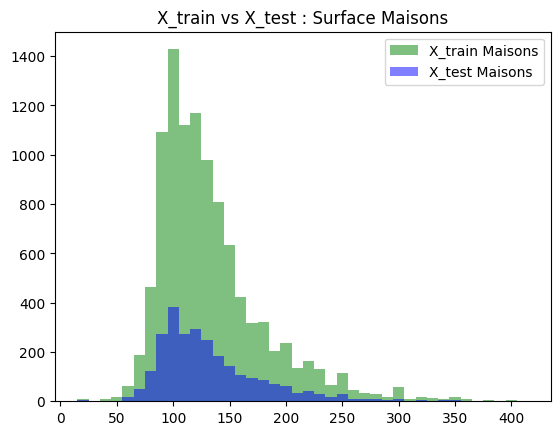

In [11]:
plt.hist(X_train_sans_scaler_maisons['surface'], color='green', alpha=0.5, label='X_train Maisons', bins=range(round(min(X_train_sans_scaler_maisons['surface'])), round(max(X_train_sans_scaler_maisons['surface'])), 10))
plt.hist(X_test_sans_scaler_maisons['surface'], color='blue', alpha=0.5, label='X_test Maisons', bins=range(round(min(X_test_sans_scaler_maisons['surface'])), round(max(X_test_sans_scaler_maisons['surface'])), 10))
plt.legend()
plt.title('X_train vs X_test : Surface Maisons')
plt.show()


# Vérification de la distribution de nb_pieces entre X_train et X_test

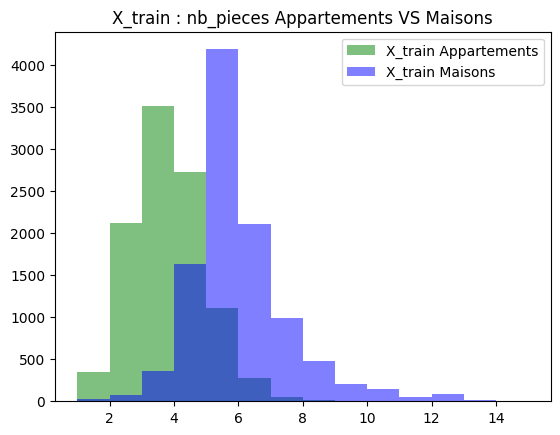

In [12]:
plt.hist(X_train_sans_scaler_appartements['nb_pieces'], color='green', alpha=0.5, label='X_train Appartements', bins=range(round(min(X_train_sans_scaler_appartements['nb_pieces'])), round(max(X_train_sans_scaler_appartements['nb_pieces'])), 1))
plt.hist(X_train_sans_scaler_maisons['nb_pieces'], color='blue', alpha=0.5, label='X_train Maisons', bins=range(round(min(X_train_sans_scaler_maisons['nb_pieces'])), round(max(X_train_sans_scaler_maisons['nb_pieces'])), 1))
plt.legend()
plt.title('X_train : nb_pieces Appartements VS Maisons')
plt.show()


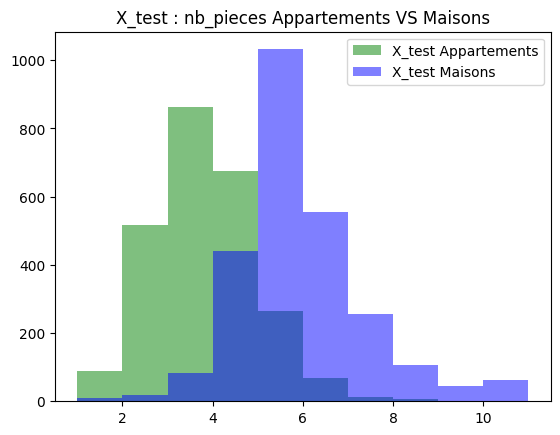

In [13]:
plt.hist(X_test_sans_scaler_appartements['nb_pieces'], color='green', alpha=0.5, label='X_test Appartements', bins=range(round(min(X_test_sans_scaler_appartements['nb_pieces'])), round(max(X_test_sans_scaler_appartements['nb_pieces'])), 1))
plt.hist(X_test_sans_scaler_maisons['nb_pieces'], color='blue', alpha=0.5, label='X_test Maisons', bins=range(round(min(X_test_sans_scaler_maisons['nb_pieces'])), round(max(X_test_sans_scaler_maisons['nb_pieces'])), 1))
plt.legend()
plt.title('X_test : nb_pieces Appartements VS Maisons')
plt.show()


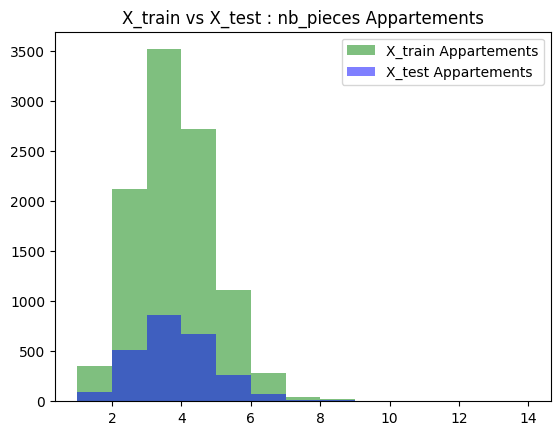

In [14]:
plt.hist(X_train_sans_scaler_appartements['nb_pieces'], color='green', alpha=0.5, label='X_train Appartements', bins=range(round(min(X_train_sans_scaler_appartements['nb_pieces'])), round(max(X_train_sans_scaler_appartements['nb_pieces'])), 1))
plt.hist(X_test_sans_scaler_appartements['nb_pieces'], color='blue', alpha=0.5, label='X_test Appartements', bins=range(round(min(X_test_sans_scaler_appartements['nb_pieces'])), round(max(X_test_sans_scaler_appartements['nb_pieces'])), 1))
plt.legend()
plt.title('X_train vs X_test : nb_pieces Appartements')
plt.show()


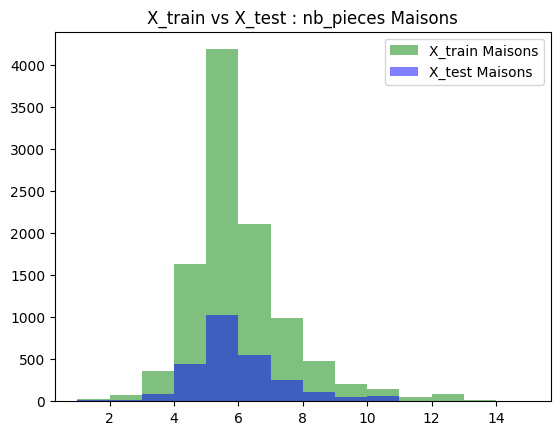

In [15]:
plt.hist(X_train_sans_scaler_maisons['nb_pieces'], color='green', alpha=0.5, label='X_train Maisons', bins=range(round(min(X_train_sans_scaler_maisons['nb_pieces'])), round(max(X_train_sans_scaler_maisons['nb_pieces'])), 1))
plt.hist(X_test_sans_scaler_maisons['nb_pieces'], color='blue', alpha=0.5, label='X_test Maisons', bins=range(round(min(X_test_sans_scaler_maisons['nb_pieces'])), round(max(X_test_sans_scaler_maisons['nb_pieces'])), 1))
plt.legend()
plt.title('X_train vs X_test : nb_pieces Maisons')
plt.show()


# DecisionTreeRegressor() sans target encoding

In [16]:
tree = DecisionTreeRegressor()

tree.fit(X_train.drop('avg_commune_type_pieces', axis=1), y_train)

tree_pred = tree.predict(X_test.drop('avg_commune_type_pieces', axis=1))
tree_pred = pd.DataFrame(tree_pred, index=y_test.index, columns=['prix_bien'])

mae_tree = mean_absolute_error(y_test, tree_pred)
rmse_tree = np.sqrt(mean_squared_error(y_test, tree_pred))
r2_tree = r2_score(y_test, tree_pred)

print(f"MAE  : {mae_tree:.2f}")
print(f"RMSE : {rmse_tree:.2f}")
print(f"R2   : {r2_tree:.4f}")

MAE  : 62771.19
RMSE : 105353.40
R2   : 0.5618


In [17]:
importance = tree.feature_importances_
feature_names = X_train.drop('avg_commune_type_pieces', axis=1).columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
display(importance_df)

,Feature,Importance
1,surface,0.504686
26,Longitude_scaled,0.103902
25,Latitude_scaled,0.044760
8,dpeC,0.040854
2,surface_terrain,0.039536
...,...,...
43,chauf_cheminee,0.000000
44,chauf_inconnu,0.000000
49,energie_inconnue,0.000000
69,chauffage_mode_inconnu,0.000000


In [18]:
tree_diff = y_test - tree_pred

<Axes: ylabel='Count'>

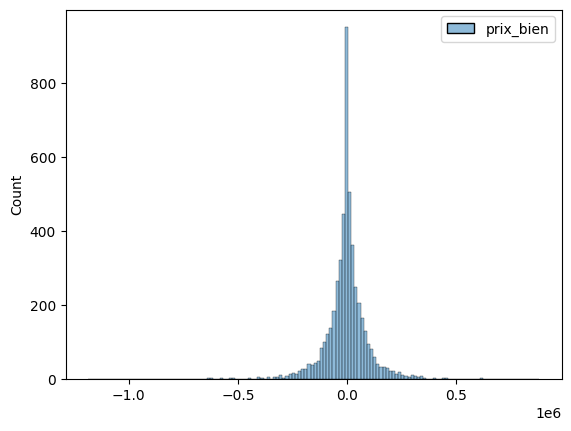

In [19]:
sns.histplot(tree_diff)

# DecisionTreeRegressor() avec target encoding

In [20]:
tree = DecisionTreeRegressor()

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)
tree_pred = pd.DataFrame(tree_pred, index=y_test.index, columns=['prix_bien'])

mae_tree = mean_absolute_error(y_test, tree_pred)
rmse_tree = np.sqrt(mean_squared_error(y_test, tree_pred))
r2_tree = r2_score(y_test, tree_pred)

print(f"MAE  : {mae_tree:.2f}")
print(f"RMSE : {rmse_tree:.2f}")
print(f"R2   : {r2_tree:.4f}")

MAE  : 62642.50
RMSE : 105526.60
R2   : 0.5603


In [21]:
importance = tree.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
display(importance_df)

,Feature,Importance
27,avg_commune_type_pieces,0.597104
1,surface,0.108046
8,dpeC,0.034413
2,surface_terrain,0.028885
12,annee_construction,0.025812
...,...,...
50,energie_inconnue,0.000000
45,chauf_inconnu,0.000000
74,typedetransaction_pi,0.000000
70,chauffage_mode_inconnu,0.000000


In [22]:
tree_diff = y_test - tree_pred

In [23]:
tree_diff

,prix_bien
idannonce,
guy-hoquet-immo-facile-5974993,-119600.0
ag680297-277810664,9300.0
orpi-1-054041E1OWKF,21050.0
guy-hoquet-immo-facile-6243822,-23000.0
ag440414-293552741,128000.0
...,...
immo-facile-35871425,-35000.0
ag680254-273036872,20000.0
ag681158-373018354,15900.0


<Axes: ylabel='Count'>

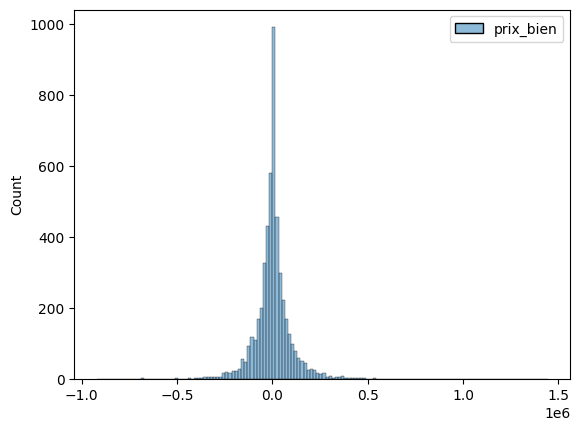

In [24]:
sns.histplot(tree_diff)

In [25]:
X_test.shape

(5127, 93)

In [26]:
df_tree_pred = pd.merge(tree_pred, df_ventes, how='left', left_index=True, right_index=True)
df_tree_pred['delta_prediction'] = df_tree_pred['prix_bien_y'] - df_tree_pred['prix_bien_x']
df_tree_pred.shape

(5127, 60)

In [27]:
df_tree_pred.sort_values(by='prix_bien_y', ascending=False)[['prix_bien_y','prix_bien_x', 'delta_prediction']].head()

,prix_bien_y,prix_bien_x,delta_prediction
idannonce,,,
ag681120-337284537,2300000,855670.0,1444330.0
immo-facile-51101837,1670000,1090000.0,580000.0
hektor-dagon68390-2443,1295000,379600.0,915400.0
immo-facile-40221393,1250000,828000.0,422000.0
safti-1-690910,1180000,988000.0,192000.0


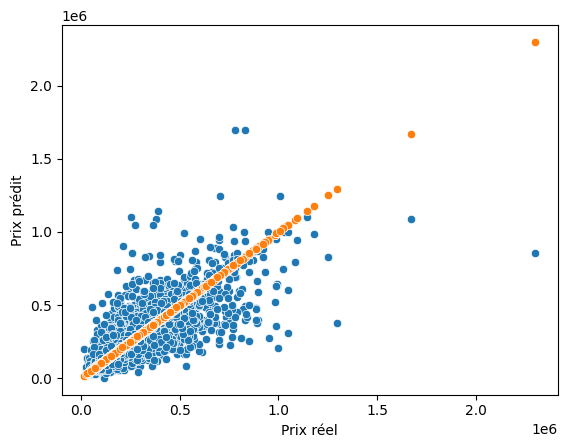

In [28]:
sns.scatterplot(data=df_tree_pred, x='prix_bien_y', y='prix_bien_x')
sns.scatterplot(data=df_tree_pred, x='prix_bien_y', y='prix_bien_y')
plt.xlabel('Prix réel')
plt.ylabel('Prix prédit');

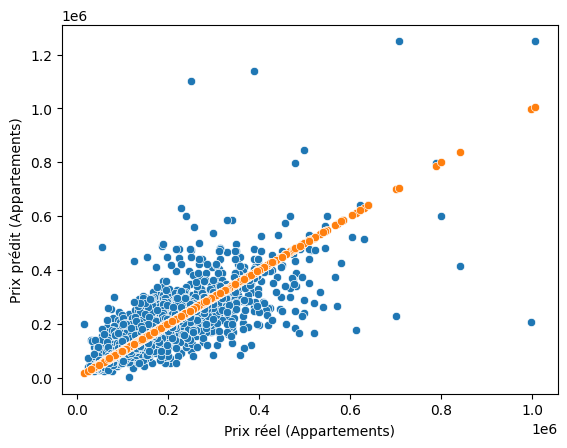

In [29]:
sns.scatterplot(data=df_tree_pred[df_tree_pred['typedebien_lite'] == 'a'], x='prix_bien_y', y='prix_bien_x')
sns.scatterplot(data=df_tree_pred[df_tree_pred['typedebien_lite'] == 'a'], x='prix_bien_y', y='prix_bien_y')
plt.xlabel('Prix réel (Appartements)')
plt.ylabel('Prix prédit (Appartements)');

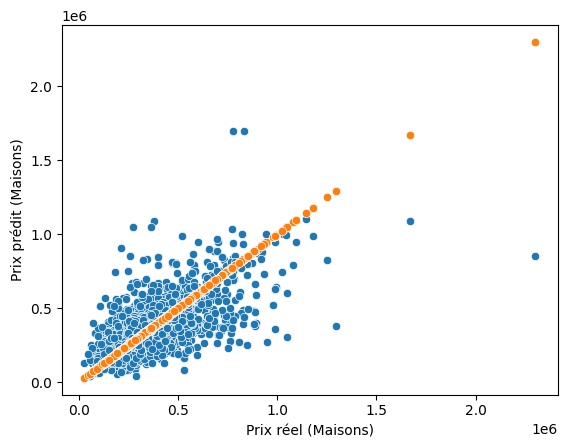

In [30]:
sns.scatterplot(data=df_tree_pred[df_tree_pred['typedebien_lite'] == 'm'], x='prix_bien_y', y='prix_bien_x')
sns.scatterplot(data=df_tree_pred[df_tree_pred['typedebien_lite'] == 'm'], x='prix_bien_y', y='prix_bien_y')
plt.xlabel('Prix réel (Maisons)')
plt.ylabel('Prix prédit (Maisons)');

In [31]:
np.abs(df_tree_pred[df_tree_pred['typedebien_lite'] == 'm']['delta_prediction']).mean()

np.float64(83154.48876190477)

In [32]:
np.abs(df_tree_pred[df_tree_pred['typedebien_lite'] == 'a']['delta_prediction']).mean()

np.float64(41122.121103117504)

In [33]:
df_train = pd.merge(X_train, df_ventes, how='left', left_index=True, right_index=True)
df_train['typedebien_lite'] == 'a'

idannonce
ag681108-285757544               True
ag680297-340567902              False
hektor-girardi-pfastatt-2683    False
orpi-1-054928E2CVGG             False
ag671791-287402273               True
                                ...  
ag440414-273408896               True
ag681391-366397327              False
orpi-1-054039E2F462             False
ag681122-315221046               True
iad-france-782156               False
Name: typedebien_lite, Length: 20569, dtype: bool

# DecisionTreeRegressor() sur Appartements

In [34]:
tree_a = DecisionTreeRegressor()

tree_a.fit(X_train[df_train['typedebien_lite'] == 'a'], y_train[df_train['typedebien_lite'] == 'a'])

tree_a_pred = tree_a.predict(X_test[df_tree_pred['typedebien_lite'] == 'a'])
tree_a_pred = pd.DataFrame(tree_a_pred, index=y_test[df_tree_pred['typedebien_lite'] == 'a'].index, columns=['prix_bien'])

mae_tree_a = mean_absolute_error(y_test[df_tree_pred['typedebien_lite'] == 'a'], tree_a_pred)
rmse_tree_a = np.sqrt(mean_squared_error(y_test[df_tree_pred['typedebien_lite'] == 'a'], tree_a_pred))
r2_tree_a = r2_score(y_test[df_tree_pred['typedebien_lite'] == 'a'], tree_a_pred)

print(f"MAE  : {mae_tree_a:.2f}")
print(f"RMSE : {rmse_tree_a:.2f}")
print(f"R2   : {r2_tree_a:.4f}")

MAE  : 40450.44
RMSE : 66769.92
R2   : 0.5662


In [35]:
df_tree_a_pred = pd.merge(tree_a_pred, df_ventes, how='left', left_index=True, right_index=True)

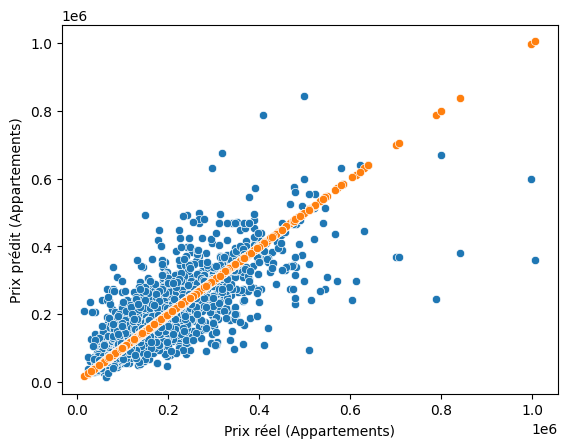

In [36]:
sns.scatterplot(data=df_tree_a_pred, x='prix_bien_y', y='prix_bien_x')
sns.scatterplot(data=df_tree_a_pred, x='prix_bien_y', y='prix_bien_y')
plt.xlabel('Prix réel (Appartements)')
plt.ylabel('Prix prédit (Appartements)');

# DecisionTreeRegressor() sur Maisons

In [37]:
tree_m = DecisionTreeRegressor()

tree_m.fit(X_train[df_train['typedebien_lite'] == 'm'], y_train[df_train['typedebien_lite'] == 'm'])

tree_m_pred = tree_m.predict(X_test[df_tree_pred['typedebien_lite'] == 'm'])
tree_m_pred = pd.DataFrame(tree_m_pred, index=y_test[df_tree_pred['typedebien_lite'] == 'm'].index, columns=['prix_bien'])

mae_tree_m = mean_absolute_error(y_test[df_tree_pred['typedebien_lite'] == 'm'], tree_m_pred)
rmse_tree_m = np.sqrt(mean_squared_error(y_test[df_tree_pred['typedebien_lite'] == 'm'], tree_m_pred))
r2_tree_m = r2_score(y_test[df_tree_pred['typedebien_lite'] == 'm'], tree_m_pred)

print(f"MAE  : {mae_tree_m:.2f}")
print(f"RMSE : {rmse_tree_m:.2f}")
print(f"R2   : {r2_tree_m:.4f}")

MAE  : 81735.08
RMSE : 129734.32
R2   : 0.3944


In [38]:
df_tree_m_pred = pd.merge(tree_m_pred, df_ventes, how='left', left_index=True, right_index=True)

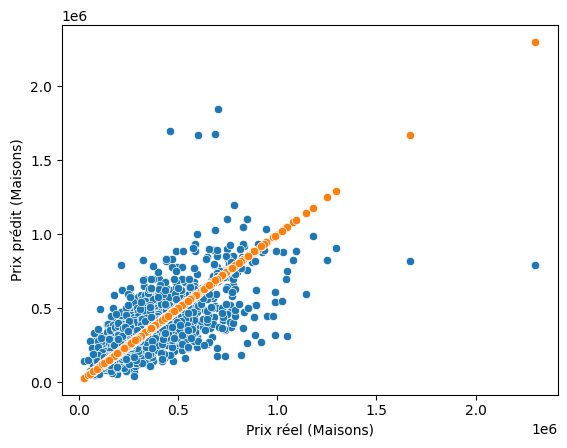

In [39]:
sns.scatterplot(data=df_tree_m_pred, x='prix_bien_y', y='prix_bien_x')
sns.scatterplot(data=df_tree_m_pred, x='prix_bien_y', y='prix_bien_y')
plt.xlabel('Prix réel (Maisons)')
plt.ylabel('Prix prédit (Maisons)');

In [40]:
X_test_maisons = X_test[df_tree_pred['typedebien_lite'] == 'm']
y_test_maisons = y_test[df_tree_pred['typedebien_lite'] == 'm']

lr_m = LinearRegression()

lr_m.fit(X_train[df_train['typedebien_lite'] == 'm'], y_train[df_train['typedebien_lite'] == 'm'])

lr_m_pred = lr_m.predict(X_test_maisons)
lr_m_pred = pd.DataFrame(lr_m_pred, index=y_test_maisons.index, columns=['prix_bien'])

mae_lr_m = mean_absolute_error(y_test_maisons, lr_m_pred)
rmse_lr_m = np.sqrt(mean_squared_error(y_test_maisons, lr_m_pred))
r2_lr_m = r2_score(y_test_maisons, lr_m_pred)

print(f"MAE  : {mae_lr_m:.2f}")
print(f"RMSE : {rmse_lr_m:.2f}")
print(f"R2   : {r2_lr_m:.4f}")

MAE  : 73803.54
RMSE : 108587.53
R2   : 0.5757


In [41]:
df_lr_m_pred = pd.merge(lr_m_pred, df_ventes, how='left', left_index=True, right_index=True)

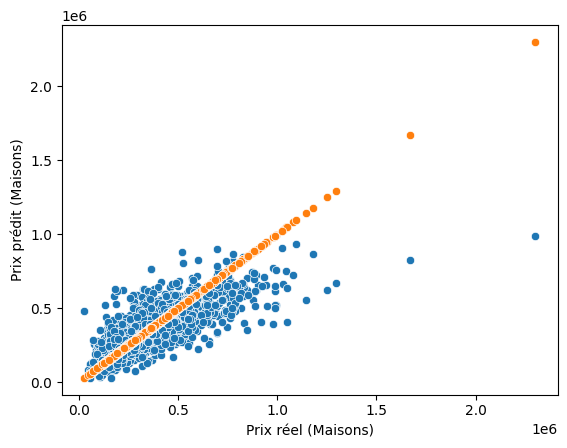

In [42]:
sns.scatterplot(data=df_lr_m_pred, x='prix_bien_y', y='prix_bien_x')
sns.scatterplot(data=df_lr_m_pred, x='prix_bien_y', y='prix_bien_y')
plt.xlabel('Prix réel (Maisons)')
plt.ylabel('Prix prédit (Maisons)');

In [43]:
X_test_maisons_sans_outlier = X_test[(df_tree_pred['typedebien_lite'] == 'm') & (df_tree_pred['prix_bien_y'] < 5000000)]
y_test_maisons_sans_outlier = y_test[(df_tree_pred['typedebien_lite'] == 'm') & (df_tree_pred['prix_bien_y'] < 5000000)]

lr_m = LinearRegression()

lr_m.fit(X_train[df_train['typedebien_lite'] == 'm'], y_train[df_train['typedebien_lite'] == 'm'])

score_pieces = []

for nb in df_tree_pred.nb_pieces.unique():

    lr_m_pred = lr_m.predict(X_test_maisons_sans_outlier[df_tree_pred['nb_pieces'] == nb])
    lr_m_pred = pd.DataFrame(lr_m_pred, index=y_test_maisons_sans_outlier[df_tree_pred['nb_pieces'] == nb].index, columns=['prix_bien'])

    mae_lr_m = mean_absolute_error(y_test_maisons_sans_outlier[df_tree_pred['nb_pieces'] == nb], lr_m_pred)
    rmse_lr_m = np.sqrt(mean_squared_error(y_test_maisons_sans_outlier[df_tree_pred['nb_pieces'] == nb], lr_m_pred))
    r2_lr_m = r2_score(y_test_maisons_sans_outlier[df_tree_pred['nb_pieces'] == nb], lr_m_pred)

    print(f"{nb} pieces :")
    print(f"MAE  : {mae_lr_m:.2f}")
    print(f"RMSE : {rmse_lr_m:.2f}")
    print(f"R2   : {r2_lr_m:.4f}")
    score_pieces.append({"pieces":nb, "MAE": mae_lr_m, "RMSE":rmse_lr_m, "R2":r2_lr_m})
    print('\n')

5 pieces :
MAE  : 60697.67
RMSE : 83433.90
R2   : 0.5691


3 pieces :
MAE  : 57361.46
RMSE : 91119.15
R2   : -0.0194


4 pieces :
MAE  : 52536.14
RMSE : 73534.18
R2   : 0.4403


7 pieces :
MAE  : 100382.74
RMSE : 138167.41
R2   : 0.6026


6 pieces :
MAE  : 77921.67
RMSE : 102993.23
R2   : 0.5366


10 pieces :
MAE  : 139718.13
RMSE : 190035.88
R2   : 0.2717


2 pieces :
MAE  : 97583.31
RMSE : 107312.30
R2   : -8.6686


9 pieces :
MAE  : 154854.83
RMSE : 215395.29
R2   : 0.3327


8 pieces :
MAE  : 135179.07
RMSE : 212232.05
R2   : 0.4387


1 pieces :
MAE  : 58221.11
RMSE : 86598.61
R2   : 0.5755


12 pieces :
MAE  : 104532.70
RMSE : 157564.32
R2   : 0.2841


11 pieces :
MAE  : 143601.54
RMSE : 203961.40
R2   : 0.2742




C:\Users\NKSP1012\AppData\Local\Temp\1\ipykernel_25084\2517993359.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  lr_m_pred = lr_m.predict(X_test_maisons_sans_outlier[df_tree_pred['nb_pieces'] == nb])
C:\Users\NKSP1012\AppData\Local\Temp\1\ipykernel_25084\2517993359.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  lr_m_pred = pd.DataFrame(lr_m_pred, index=y_test_maisons_sans_outlier[df_tree_pred['nb_pieces'] == nb].index, columns=['prix_bien'])
C:\Users\NKSP1012\AppData\Local\Temp\1\ipykernel_25084\2517993359.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mae_lr_m = mean_absolute_error(y_test_maisons_sans_outlier[df_tree_pred['nb_pieces'] == nb], lr_m_pred)
C:\Users\NKSP1012\AppData\Local\Temp\1\ipykernel_25084\2517993359.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  rmse_lr_m = np.sqrt(mean_squared_error(y_test_maisons_sans_outlier[df_tr

In [44]:
pd.DataFrame(score_pieces).sort_values(by='pieces')

,pieces,MAE,RMSE,R2
9,1,58221.107919,86598.605133,0.575546
6,2,97583.311152,107312.304409,-8.668557
1,3,57361.457295,91119.149517,-0.019443
2,4,52536.136081,73534.177707,0.440252
0,5,60697.666420,83433.898629,0.569116
4,6,77921.668455,102993.228643,0.536616
3,7,100382.738037,138167.408651,0.602644
8,8,135179.065489,212232.054070,0.438691
7,9,154854.825595,215395.285901,0.332672
5,10,139718.132105,190035.883234,0.271654


In [45]:
df_lr_m_pred = pd.merge(lr_m_pred, df_ventes, how='left', left_index=True, right_index=True)

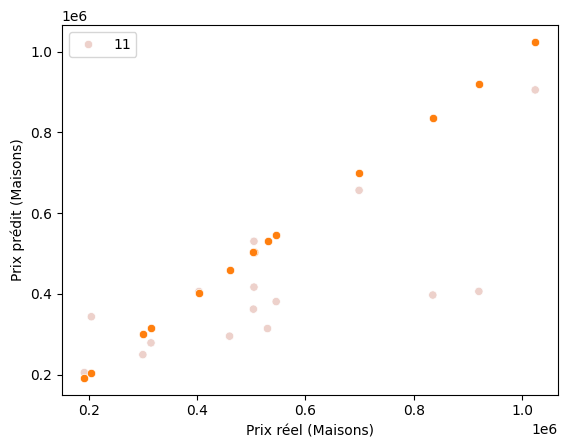

In [46]:
for nb in df_lr_m_pred.nb_pieces.unique():
    sns.scatterplot(data=df_lr_m_pred[df_lr_m_pred['nb_pieces'] == nb], x='prix_bien_y', y='prix_bien_x', hue='nb_pieces')
    sns.scatterplot(data=df_lr_m_pred[df_lr_m_pred['nb_pieces'] == nb], x='prix_bien_y', y='prix_bien_y')
    plt.xlabel('Prix réel (Maisons)')
    plt.ylabel('Prix prédit (Maisons)')
    plt.show()
    print('\n');

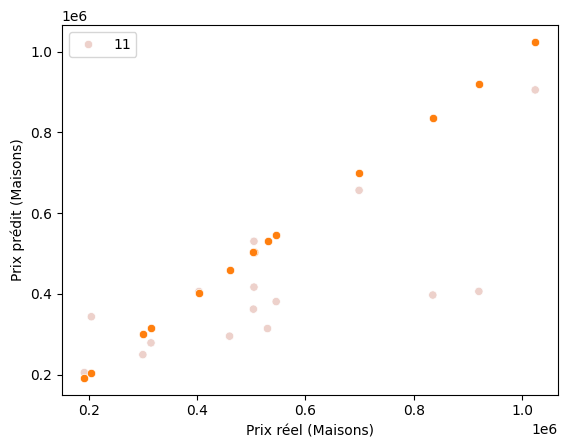

In [47]:
sns.scatterplot(data=df_lr_m_pred, x='prix_bien_y', y='prix_bien_x', hue='nb_pieces')
sns.scatterplot(data=df_lr_m_pred, x='prix_bien_y', y='prix_bien_y')
plt.xlabel('Prix réel (Maisons)')
plt.ylabel('Prix prédit (Maisons)');

In [48]:
X_test_appartements = X_test[(df_tree_pred['typedebien_lite'] == 'a')]
y_test_appartements = y_test[(df_tree_pred['typedebien_lite'] == 'a')]

lr_m = LinearRegression()

lr_m.fit(X_train[df_train['typedebien_lite'] == 'a'], y_train[df_train['typedebien_lite'] == 'a'])

score_pieces_a = []

for nb in df_tree_pred.nb_pieces.unique():
    try:
        lr_m_pred = lr_m.predict(X_test_appartements[df_tree_pred['nb_pieces'] == nb])
        lr_m_pred = pd.DataFrame(lr_m_pred, index=y_test_appartements[df_tree_pred['nb_pieces'] == nb].index, columns=['prix_bien'])

        mae_lr_m = mean_absolute_error(y_test_appartements[df_tree_pred['nb_pieces'] == nb], lr_m_pred)
        rmse_lr_m = np.sqrt(mean_squared_error(y_test_appartements[df_tree_pred['nb_pieces'] == nb], lr_m_pred))
        r2_lr_m = r2_score(y_test_appartements[df_tree_pred['nb_pieces'] == nb], lr_m_pred)

        print(f"{nb} pieces :")
        print(f"MAE  : {mae_lr_m:.2f}")
        print(f"RMSE : {rmse_lr_m:.2f}")
        print(f"R2   : {r2_lr_m:.4f}")
        score_pieces_a.append({"pieces":nb, "MAE": mae_lr_m, "RMSE":rmse_lr_m, "R2":r2_lr_m})
        print('\n')
    except:
        pass

C:\Users\NKSP1012\AppData\Local\Temp\1\ipykernel_25084\255812850.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  lr_m_pred = lr_m.predict(X_test_appartements[df_tree_pred['nb_pieces'] == nb])
C:\Users\NKSP1012\AppData\Local\Temp\1\ipykernel_25084\255812850.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  lr_m_pred = pd.DataFrame(lr_m_pred, index=y_test_appartements[df_tree_pred['nb_pieces'] == nb].index, columns=['prix_bien'])
C:\Users\NKSP1012\AppData\Local\Temp\1\ipykernel_25084\255812850.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mae_lr_m = mean_absolute_error(y_test_appartements[df_tree_pred['nb_pieces'] == nb], lr_m_pred)
C:\Users\NKSP1012\AppData\Local\Temp\1\ipykernel_25084\255812850.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  rmse_lr_m = np.sqrt(mean_squared_error(y_test_appartements[df_tree_pred['nb_pieces'] == nb], lr_m_pr

5 pieces :
MAE  : 60966.78
RMSE : 89753.98
R2   : 0.5552


3 pieces :
MAE  : 33445.31
RMSE : 44111.10
R2   : 0.6243


4 pieces :
MAE  : 41280.47
RMSE : 56236.26
R2   : 0.6543


7 pieces :
MAE  : 112598.05
RMSE : 130095.44
R2   : 0.5788


6 pieces :
MAE  : 87390.64
RMSE : 111652.58
R2   : 0.5611


10 pieces :
MAE  : 216616.09
RMSE : 247057.29
R2   : -151.5933


2 pieces :
MAE  : 26301.25
RMSE : 34129.53
R2   : 0.4677


8 pieces :
MAE  : 127971.67
RMSE : 152547.35
R2   : -0.4928


1 pieces :
MAE  : 33309.43
RMSE : 48839.81
R2   : -0.0050


12 pieces :
MAE  : 220126.77
RMSE : 220126.77
R2   : nan




In [49]:
pd.DataFrame(score_pieces_a).sort_values(by='pieces')

,pieces,MAE,RMSE,R2
8,1,33309.426799,48839.810318,-0.004977
6,2,26301.245837,34129.528773,0.467714
1,3,33445.308360,44111.103490,0.624281
2,4,41280.466099,56236.255626,0.654331
0,5,60966.780802,89753.982647,0.555219
4,6,87390.640626,111652.581537,0.561059
3,7,112598.052643,130095.442659,0.578756
7,8,127971.668274,152547.347139,-0.492765
5,10,216616.091888,247057.286766,-151.593257
9,12,220126.767280,220126.767280,NaN


In [50]:
from sklearn.ensemble import RandomForestRegressor

In [51]:
rf = RandomForestRegressor().fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_pred = pd.DataFrame(rf_pred, index=y_test.index, columns=['prix_bien'])

mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
r2_rf = r2_score(y_test, rf_pred)

print(f"MAE  : {mae_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"R2   : {r2_rf:.4f}")

c:\Users\NKSP1012\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


MAE  : 47699.43
RMSE : 80912.82
R2   : 0.7415


In [52]:
rf_pred_maisons = rf.predict(X_test_maisons)
rf_pred_maisons = pd.DataFrame(rf_pred_maisons, index=y_test_maisons.index, columns=['prix_bien'])

mae_rf_maisons = mean_absolute_error(y_test_maisons, rf_pred_maisons)
rmse_rf_maisons = np.sqrt(mean_squared_error(y_test_maisons, rf_pred_maisons))
r2_rf_maisons = r2_score(y_test_maisons, rf_pred_maisons)

print(f"MAE  : {mae_rf_maisons:.2f}")
print(f"RMSE : {rmse_rf_maisons:.2f}")
print(f"R2   : {r2_rf_maisons:.4f}")

MAE  : 64062.44
RMSE : 101526.39
R2   : 0.6291


In [53]:
rf_pred_appartements = rf.predict(X_test_appartements)
rf_pred_appartements = pd.DataFrame(rf_pred_appartements, index=y_test_appartements.index, columns=['prix_bien'])

mae_rf_appartements = mean_absolute_error(y_test_appartements, rf_pred_appartements)
rmse_rf_appartements = np.sqrt(mean_squared_error(y_test_appartements, rf_pred_appartements))
r2_rf_appartements = r2_score(y_test_appartements, rf_pred_appartements)

print(f"MAE  : {mae_rf_appartements:.2f}")
print(f"RMSE : {rmse_rf_appartements:.2f}")
print(f"R2   : {r2_rf_appartements:.4f}")

MAE  : 30532.01
RMSE : 51002.76
R2   : 0.7469


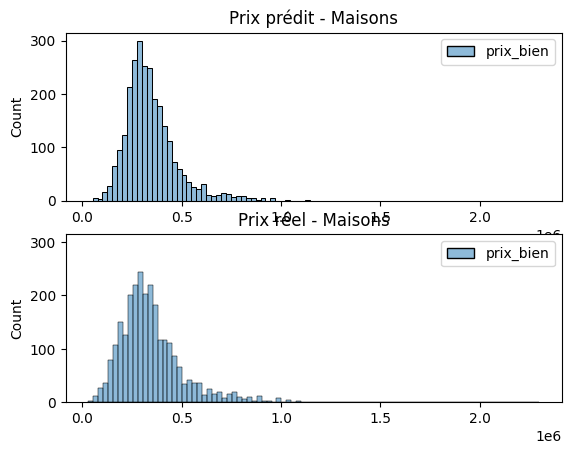

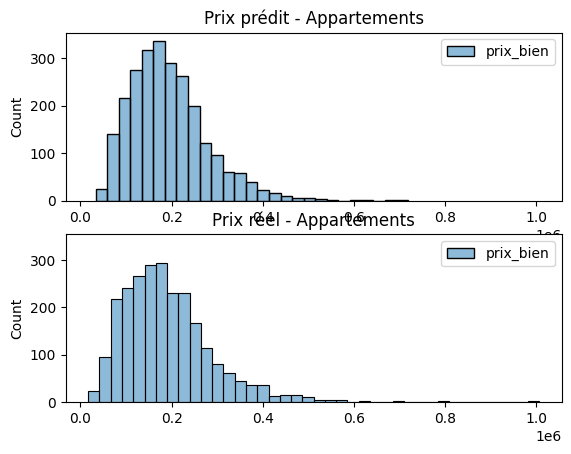

In [54]:
ax1 = plt.subplot(2,1,1)
sns.histplot(rf_pred_maisons, binwidth=25000)
plt.title('Prix prédit - Maisons')
ax2 = plt.subplot(2,1,2, sharex=ax1, sharey=ax1)
sns.histplot(y_test_maisons, binwidth=25000)
plt.title('Prix réel - Maisons')
plt.show()
ax1 = plt.subplot(2,1,1)
sns.histplot(rf_pred_appartements, binwidth=25000)
plt.title('Prix prédit - Appartements')
ax2 = plt.subplot(2,1,2, sharex=ax1, sharey=ax1)
sns.histplot(y_test_appartements, binwidth=25000)
plt.title('Prix réel - Appartements')
plt.show()

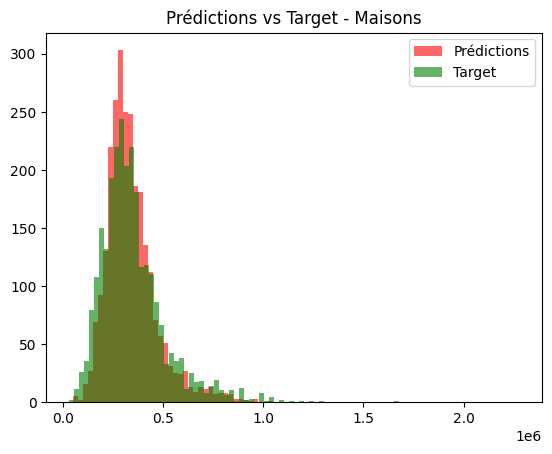

In [55]:
plt.hist(rf_pred_maisons, bins=range(round(min(rf_pred_maisons['prix_bien'])), round(max(rf_pred_maisons['prix_bien'])), 25000), color='red', alpha=0.6, label='Prédictions')
plt.hist(y_test_maisons, bins=range(round(min(y_test_maisons['prix_bien'])), round(max(y_test_maisons['prix_bien'])), 25000), color='green', alpha=0.6, label='Target')
plt.legend()
plt.title('Prédictions vs Target - Maisons')
plt.show()


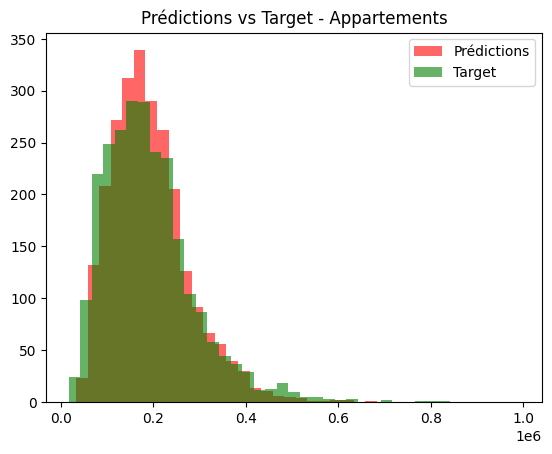

In [56]:
plt.hist(rf_pred_appartements, bins=range(round(min(rf_pred_appartements['prix_bien'])), round(max(rf_pred_appartements['prix_bien'])), 25000), color='red', alpha=0.6, label='Prédictions')
plt.hist(y_test_appartements, bins=range(round(min(y_test_appartements['prix_bien'])), round(max(y_test_appartements['prix_bien'])), 25000), color='green', alpha=0.6, label='Target')
plt.legend()
plt.title('Prédictions vs Target - Appartements')
plt.show()


In [57]:
delta_appartements = y_test_appartements - rf_pred_appartements
delta_appartements.head()

,prix_bien
idannonce,
guy-hoquet-immo-facile-5974993,-196639.26
ag680297-277810664,-3.54
orpi-1-054041E1OWKF,7363.55
guy-hoquet-immo-facile-6243822,-10651.80
ag440414-293552741,100941.30


In [58]:
delta_maisons = y_test_maisons - rf_pred_maisons
delta_maisons.head()

,prix_bien
idannonce,
hektor-CGAIMMOBILIER-913,-68917.70
immo-facile-51717740,-28041.63
orpi-1-054932E20PLN,-54320.85
ag681156-273638219,-18859.29
mgc-343363639-pp-220513-102302,68847.53


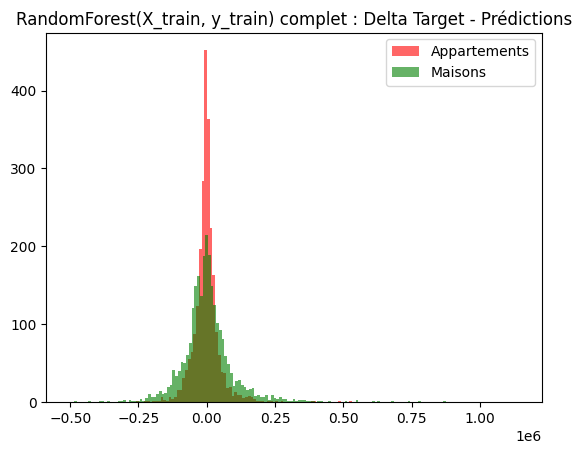

In [59]:
plt.hist(delta_appartements, bins=range(round(min(delta_appartements['prix_bien'])), round(max(delta_appartements['prix_bien'])), 10000), color='red', alpha=0.6, label='Appartements')
plt.hist(delta_maisons, bins=range(round(min(delta_maisons['prix_bien'])), round(max(delta_maisons['prix_bien'])), 10000), color='green', alpha=0.6, label='Maisons')
plt.legend()
plt.title('RandomForest(X_train, y_train) complet : Delta Target - Prédictions')
plt.show()

In [60]:
X_test_appartements = X_test[(df_tree_pred['typedebien_lite'] == 'a')]
y_test_appartements = y_test[(df_tree_pred['typedebien_lite'] == 'a')]

In [61]:
df_train = pd.merge(y_train, df_ventes, how='left', left_index=True, right_index=True)
df_train['delta_prediction'] = df_train['prix_bien_y'] - df_train['prix_bien_x']
df_train.shape

X_train_appartements = X_train[(df_train['typedebien_lite'] == 'a')]
y_train_appartements = y_train[(df_train['typedebien_lite'] == 'a')]

X_train_maisons = X_train[(df_train['typedebien_lite'] == 'm')]
y_train_maisons = y_train[(df_train['typedebien_lite'] == 'm')]

In [62]:
rf_a = RandomForestRegressor().fit(X_train_appartements, y_train_appartements)

rf_pred_a = rf.predict(X_test_appartements)
rf_pred_a = pd.DataFrame(rf_pred_a, index=y_test_appartements.index, columns=['prix_bien'])

mae_rf_a = mean_absolute_error(y_test_appartements, rf_pred_a)
rmse_rf_a = np.sqrt(mean_squared_error(y_test_appartements, rf_pred_a))
r2_rf_a = r2_score(y_test_appartements, rf_pred_a)

print(f"MAE  : {mae_rf_a:.2f}")
print(f"RMSE : {rmse_rf_a:.2f}")
print(f"R2   : {r2_rf_a:.4f}")

c:\Users\NKSP1012\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


MAE  : 30532.01
RMSE : 51002.76
R2   : 0.7469


In [63]:
delta_rf_appartements = y_test_appartements - rf_pred_a
delta_rf_appartements.head()

,prix_bien
idannonce,
guy-hoquet-immo-facile-5974993,-196639.26
ag680297-277810664,-3.54
orpi-1-054041E1OWKF,7363.55
guy-hoquet-immo-facile-6243822,-10651.80
ag440414-293552741,100941.30


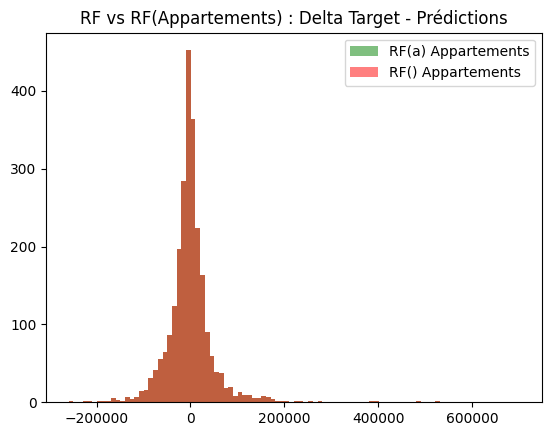

In [64]:
plt.hist(delta_rf_appartements, bins=range(round(min(delta_rf_appartements['prix_bien'])), round(max(delta_rf_appartements['prix_bien'])), 10000), color='green', alpha=0.5, label='RF(a) Appartements')
plt.hist(delta_appartements, bins=range(round(min(delta_appartements['prix_bien'])), round(max(delta_appartements['prix_bien'])), 10000), color='red', alpha=0.5, label='RF() Appartements')
plt.legend()
plt.title('RF vs RF(Appartements) : Delta Target - Prédictions')
plt.show()

In [65]:
rf_pred_m = rf.predict(X_test_maisons)
rf_pred_m = pd.DataFrame(rf_pred_m, index=y_test_maisons.index, columns=['prix_bien'])

print("MAE : ", mean_absolute_error(y_test_maisons, rf_pred_m))
print("RMSE : ", np.sqrt(mean_squared_error(y_test_maisons, rf_pred_m)))
print("R2 : ", r2_score(y_test_maisons, rf_pred_m))

MAE :  64062.436327619056
RMSE :  101526.38658805205
R2 :  0.6291044692538001


In [66]:
rf_m = RandomForestRegressor().fit(X_train_maisons, y_train_maisons)

rf_pred_m = rf.predict(X_test_maisons)
rf_pred_m = pd.DataFrame(rf_pred_m, index=y_test_maisons.index, columns=['prix_bien'])

mae_rf_m = mean_absolute_error(y_test_maisons, rf_pred_m)
rmse_rf_m = np.sqrt(mean_squared_error(y_test_maisons, rf_pred_m))
r2_rf_m = r2_score(y_test_maisons, rf_pred_m)

print(f"MAE  : {mae_rf_m:.2f}")
print(f"RMSE : {rmse_rf_m:.2f}")
print(f"R2   : {r2_rf_m:.4f}")

c:\Users\NKSP1012\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


MAE  : 64062.44
RMSE : 101526.39
R2   : 0.6291


In [67]:
delta_rf_maisons = y_test_maisons - rf_pred_m
delta_rf_maisons.head()

,prix_bien
idannonce,
hektor-CGAIMMOBILIER-913,-68917.70
immo-facile-51717740,-28041.63
orpi-1-054932E20PLN,-54320.85
ag681156-273638219,-18859.29
mgc-343363639-pp-220513-102302,68847.53


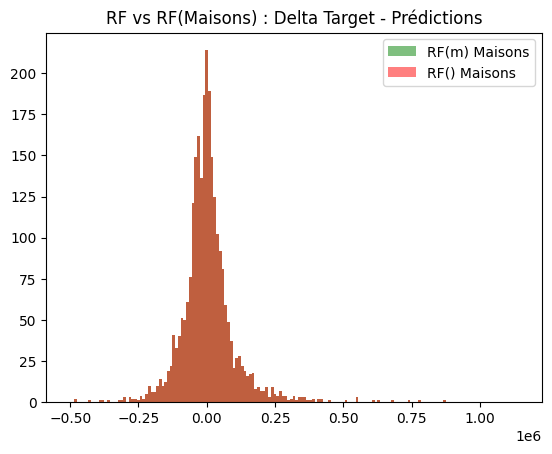

In [68]:
plt.hist(delta_rf_maisons, bins=range(round(min(delta_rf_maisons['prix_bien'])), round(max(delta_rf_maisons['prix_bien'])), 10000), color='green', alpha=0.5, label='RF(m) Maisons')
plt.hist(delta_maisons, bins=range(round(min(delta_maisons['prix_bien'])), round(max(delta_maisons['prix_bien'])), 10000), color='red', alpha=0.5, label='RF() Maisons')
plt.legend()
plt.title('RF vs RF(Maisons) : Delta Target - Prédictions')
plt.show()